In [3]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
pd.set_option('display.max_columns', None)

In [4]:
# Carga de datasets

df_hr_limpio = pd.read_csv('../df_hr_limpio.csv')

In [5]:
## para ver por que la gente se va se me ocurre que tendriamos que ver 


# comparar los empleados que se han ido, con los que se han quedado, para ver si hay alguna diferencia entre ellos:
# - si eran hombres o mujeres CAROL
# - si llevaban mucho tiempo con el mismo responsable o si es el mismo responsable el de todos los que se van CAROL
# - WorkLifeBalance CAROL

### 1) comparar los empleados que se han ido, con los que se han quedado, para ver si hay alguna diferencia entre ellos:
### - Si viajaban mucho o no ?

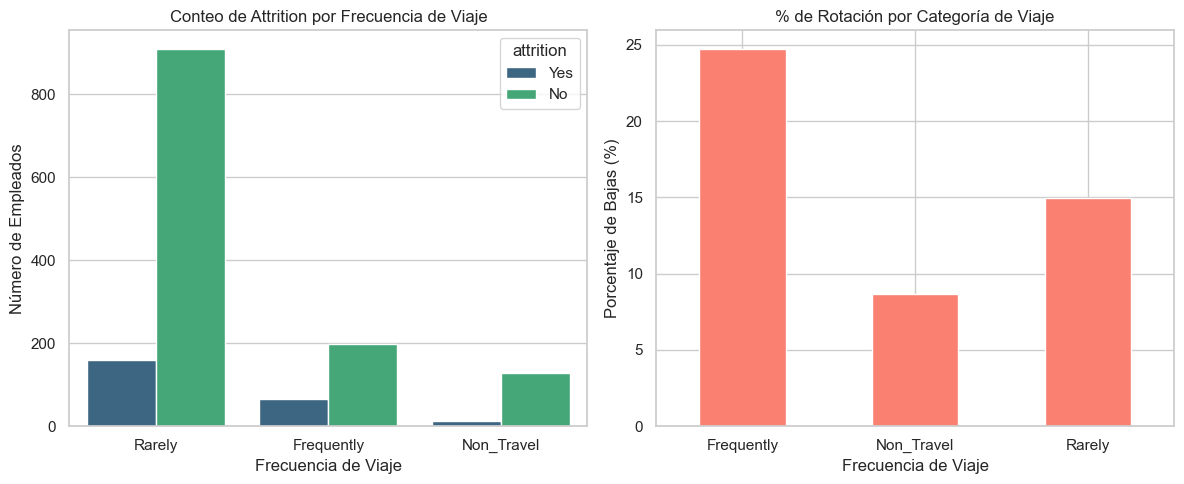

In [15]:
# 1. Bar plot: Absolute counts
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='business_travel', hue='attrition', data=df_hr_limpio, palette='viridis')
plt.title('Conteo de Attrition por Frecuencia de Viaje')
plt.xlabel('Frecuencia de Viaje')
plt.ylabel('Número de Empleados')

# 2. Percentage plot: Relative rate
plt.subplot(1, 2, 2)
travel_attrition = pd.crosstab(df_hr_limpio['business_travel'], df_hr_limpio['attrition'], normalize='index') * 100
travel_attrition['Yes'].plot(kind='bar', color='salmon')
plt.title('% de Rotación por Categoría de Viaje')
plt.xlabel('Frecuencia de Viaje')
plt.ylabel('Porcentaje de Bajas (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Viajeros Frecuentes (frequently): Tienen la tasa de rotación más alta con un 24.7%. Casi 1 de cada 4 empleados que viajan mucho termina yéndose.

Viajeros Ocasionales (rarely): Se encuentran en un punto medio con un 15% de rotación. Es el grupo más numerosa de la empresa.

No Viajeros (non_travel): Tienen la tasa más baja, apenas un 8.6%. Son los empleados más estables.

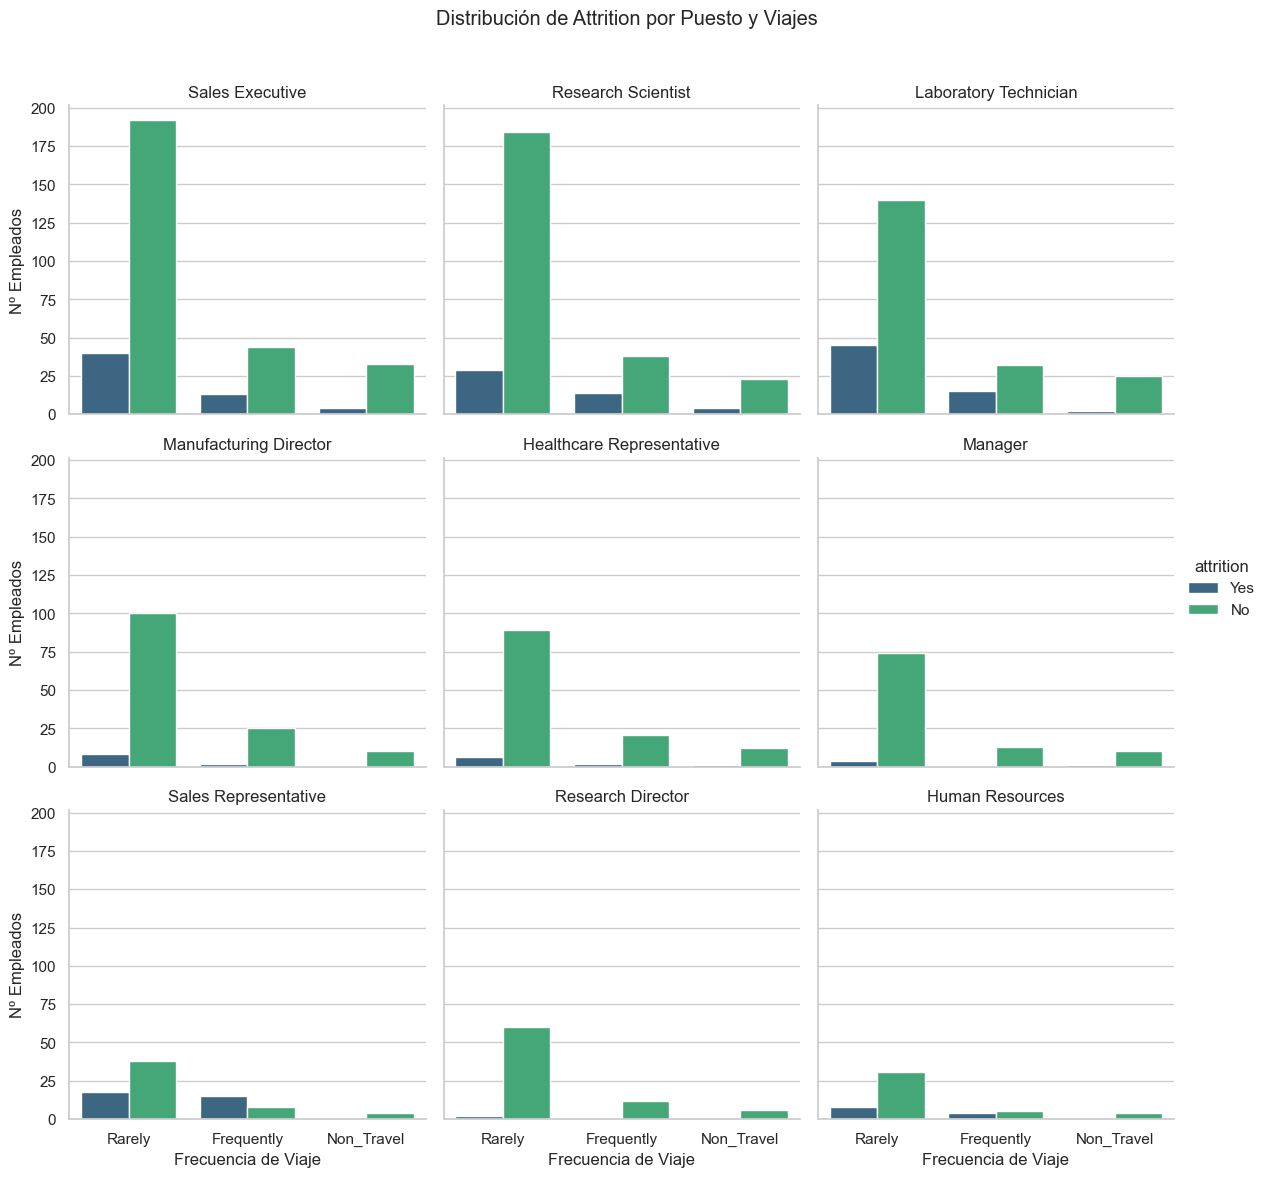

In [16]:
# Also a faceted bar chart for better comparison
g = sns.catplot(
    data=df_hr_limpio, x='business_travel', hue='attrition', col='job_role',
    kind='count', col_wrap=3, height=4, aspect=1, palette='viridis'
)
g.set_axis_labels("Frecuencia de Viaje", "Nº Empleados")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribución de Attrition por Puesto y Viajes')
plt.show()

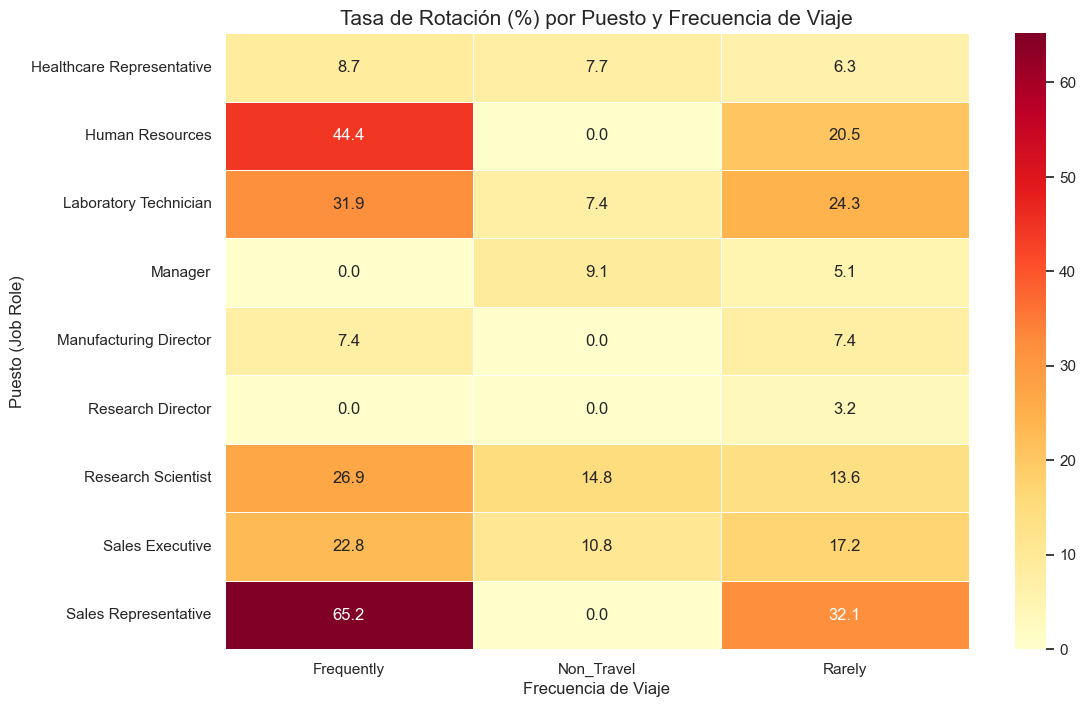

In [17]:
# Calculate attrition rate by Job Role and Business Travel
# We group by both and calculate the percentage of 'Yes' in attrition
analysis = df_hr_limpio.groupby(['job_role', 'business_travel'])['attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
analysis.columns = ['Job Role', 'Business Travel', 'Attrition Rate (%)']

# Create the heatmap/pivot for a clear visualization
pivot_analysis = analysis.pivot(index='Job Role', columns='Business Travel', values='Attrition Rate (%)')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_analysis, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5)
plt.title('Tasa de Rotación (%) por Puesto y Frecuencia de Viaje', fontsize=15)
plt.xlabel('Frecuencia de Viaje', fontsize=12)
plt.ylabel('Puesto (Job Role)', fontsize=12)
plt.show()

### 1) comparar los empleados que se han ido, con los que se han quedado, para ver si hay alguna diferencia entre ellos:
### - Impacto del Tiempo desde el Último Ascenso en la Rotación' ? YearsSinceLastPromotion

C:\Users\eliab\AppData\Local\Temp\ipykernel_8592\1875190136.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='years_since_last_promotion', y='attrition_percentage', data=attrition_rate, palette='magma')


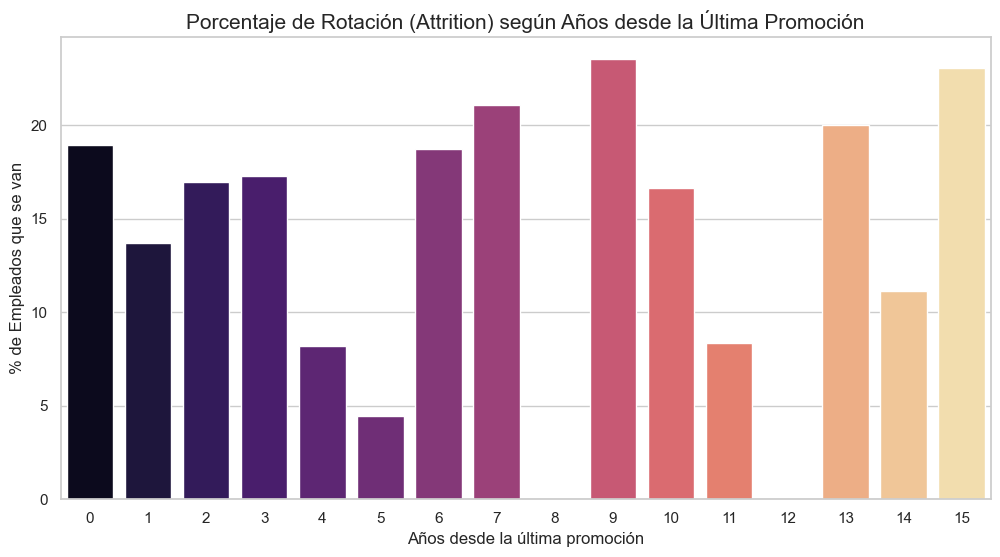

In [13]:
# Calculate attrition rate for each year since last promotion
attrition_rate = df_hr_limpio.groupby('years_since_last_promotion')['attrition'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
attrition_rate.columns = ['years_since_last_promotion', 'attrition_percentage']

# Plot 1: Percentage of Attrition by Years Since Last Promotion
plt.figure(figsize=(12, 6))
sns.barplot(x='years_since_last_promotion', y='attrition_percentage', data=attrition_rate, palette='magma')
plt.title('Porcentaje de Rotación (Attrition) según Años desde la Última Promoción', fontsize=15)
plt.xlabel('Años desde la última promoción', fontsize=12)
plt.ylabel('% de Empleados que se van', fontsize=12)
plt.show();

### 1) comparar los empleados que se han ido, con los que se han quedado, para ver si hay alguna diferencia entre ellos:
### - stock_option_level se refiere al nivel de opciones sobre acciones que la compañía ofrece a un empleado como parte de su compensación. Ver si los que dimitieron tenian acciones

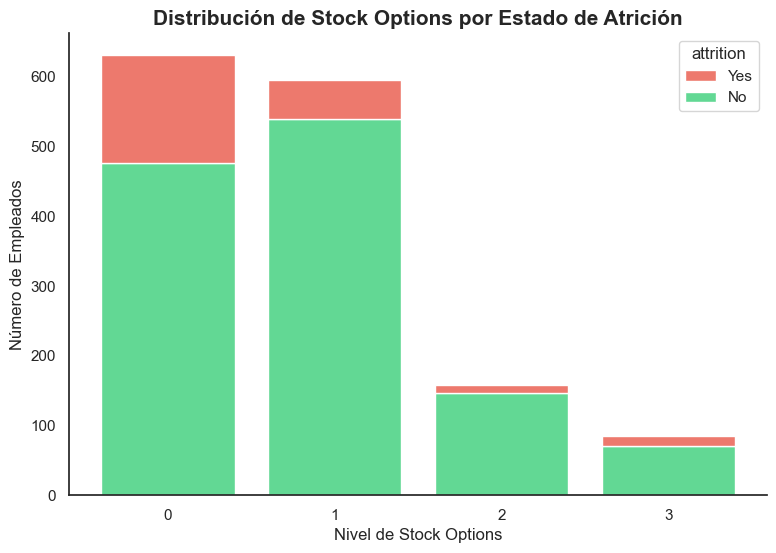

In [ ]:
plt.figure(figsize=(9, 6))

# El histplot es ideal para ver distribuciones
sns.histplot(
    data=df_hr_limpio, 
    x='stock_option_level', 
    hue='attrition', 
    multiple='stack',      # Apila las barras para ver el total y la parte que se va
    palette={'Yes': '#e74c3c', 'No': '#2ecc71'}, # Rojo para fuga, Verde para permanencia
    shrink=0.8,            # Deja un poco de espacio entre barras para que se vea limpio
    discrete=True          # Al ser niveles 0,1,2,3, le decimos que son valores discretos
)

# Mejoras visuales
plt.title('Distribución de Stock Options por Estado de Atrición', fontsize=15, fontweight='bold')
plt.xlabel('Nivel de Stock Options', fontsize=12)
plt.ylabel('Número de Empleados', fontsize=12)
plt.xticks([0, 1, 2, 3]) # Aseguramos que solo se vean los niveles reales

# Limpiamos el borde superior y derecho
sns.despine()

plt.show()